# Assignment 2: House Price Prediction, Bengaluru Housing Data

**Anshuman Atrey** · Roll No. 150096724029 · B.Tech CSE 2024-28, Semester V · Machine Learning Fundamentals (Google Classroom, ML(Elon Musk))

| | |
|---|------------------|
| **dataset** | [Bengaluru House price data](https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data) on kaggle: 13,320 listings, 9 columns |
| **my subset** | locations starting with **A** (first letter of Anshuman). the extra rule "bathrooms >= 9" (last digit of my roll number) left 1 row, so as the handout says it was dropped, leaving the location filter only |
| **target** | `price` in lakh rupees (1 lakh = 1,00,000) |
| **model** | Linear Regression on area, BHK, bathrooms and location (one-hot) |
| **result** | **test R-squared 0.897** (train 0.873, 5-fold cross-validation 0.855 ± 0.026), pass condition 0.75 |

## the whole thing in plain words

for anyone who has never touched machine learning:

1. **The task:** predict the price of a flat in Bengaluru from its size, number of bedrooms (BHK), bathrooms and location, using Linear Regression.
2. **My slice of the data:** the class rule is that every student works on a different subset. Mine is every location starting with "A" (for Anshuman): 568 listings across 85 locations.
3. **Cleaning:** some areas were written as ranges ("2100-2850"), so I took the middle. Three were in land units like acres, which are plots, not flats, so they went. Missing and repeated rows went too, leaving 536.
4. **Prices are lopsided:** most flats cost under ₹1.5 crore, but a few cost up to ₹29 crore. Taking the logarithm of the price squashes that long tail into a bell shape that a straight-line model handles much better.
5. **What drives price:** area matters most (correlation 0.71). Bedrooms and bathrooms go almost hand in hand (0.89) and add little once area is known. Location changes price over 5 times between the cheapest and costliest "A" areas.
6. **The first model was bad:** the plain model explained only 40% of the price differences on flats it hadn't seen (test R² 0.40), and on other splits it did even worse.
7. **Step by step it got better:** log of price, removing impossible listings (under 300 sq ft per bedroom), dropping listings priced way off their own neighbourhood, grouping rare locations, and log of area.
8. **The final model:** test R² 0.897, so it explains about 90% of the price differences on flats it never saw. The pass mark was 0.75.
9. **Not overfitting:** the training R² is 0.873, almost the same as the test score, and 5 different splits average 0.855, so it isn't memorising.
10. **What it learned:** a 10% bigger flat costs about 11.5% more. Once size is known, an extra bedroom barely changes the price. Location moves it from about 37% below to 92% above the baseline area.
11. **Limitations:** the outlier steps dropped 125 listings, so the model is meant for typical flats, not mansions or bargains. Its typical error is about ₹14 lakh.
12. **What gets handed in:** the notebook, a 1-page summary PDF, and this report (PDF and Word) with every step's explanation, code and output screenshot.

## 1. setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

SEED = 42                                  # same split every run
FIG = Path("figures")
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.2 | numpy 2.2.6


## 2. loading the data and personalising the subset

the handout makes every student work on a different slice. mine: locations whose name starts with my first letter, **A**, and bathrooms >= the last digit of my roll number (**9**). if that leaves fewer than 150 rows, the bathroom rule goes.

In [2]:
df = pd.read_csv("data/Bengaluru_House_Data.csv")
df["location"] = df["location"].str.strip()
print(f"full dataset: {df.shape[0]} rows x {df.shape[1]} columns")

starts_with_a = df["location"].fillna("").str.lower().str.startswith("a")
both_rules = starts_with_a & (df["bath"] >= 9)
print(f"locations starting with 'A': {starts_with_a.sum()} rows")
print(f"... and bathrooms >= 9: {both_rules.sum()} rows -> fewer than 150, so the bathroom rule is dropped")

data = df[starts_with_a].copy()
print(f"my subset: {len(data)} rows, {data['location'].nunique()} different locations")
data.head()

full dataset: 13320 rows x 9 columns
locations starting with 'A': 568 rows
... and bathrooms >= 9: 1 rows -> fewer than 150, so the bathroom rule is dropped
my subset: 568 rows, 85 different locations


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
50,Super built-up Area,Ready To Move,Adarsh Nagar,2 BHK,Bhncyis,1270,2.0,1.0,50.00
121,Super built-up Area,Ready To Move,Akshaya Nagar,3 BHK,HiahsLa,2061,3.0,1.0,200.00
144,Super built-up Area,17-Jul,Anandapura,2 BHK,ViensRK,1167,2.0,1.0,43.76
171,Super built-up Area,Ready To Move,Attibele,1 BHK,Jae 1hu,450,1.0,1.0,11.00
243,Super built-up Area,Ready To Move,Ashwath Nagar,3 BHK,SJcerpe,1644,3.0,3.0,84.00


## 3. EDA: shape, types, missing values, duplicates, outliers

In [3]:
print("shape:", data.shape)
print("types:", {c: str(t) for c, t in data.dtypes.items()})
print("\nmissing values:", data.isna().sum()[lambda s: s > 0].to_dict())
print("duplicate rows:", int(data.duplicated().sum()))

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())

area_numeric = pd.to_numeric(data["total_sqft"], errors="coerce")
print(f"\noutliers by the 1.5 x IQR rule: price {iqr_outliers(data['price'])}, "
      f"area {iqr_outliers(area_numeric.dropna())}")
print("non-numeric total_sqft examples:",
      data.loc[area_numeric.isna(), "total_sqft"].unique()[:8].tolist())
data[["price", "bath", "balcony"]].describe().round(1)

shape: (568, 9)
types: {'area_type': 'object', 'availability': 'object', 'location': 'object', 'size': 'object', 'society': 'object', 'total_sqft': 'object', 'bath': 'float64', 'balcony': 'float64', 'price': 'float64'}

missing values: {'size': 1, 'society': 278, 'bath': 1, 'balcony': 26}
duplicate rows: 15

outliers by the 1.5 x IQR rule: price 39, area 33
non-numeric total_sqft examples: ['4125Perch', '660 - 780', '38Guntha', '6Acres']


,price,bath,balcony
count,568.0,567.0,542.0
mean,90.2,2.5,1.5
std,139.6,1.2,0.8
min,10.0,1.0,0.0
25%,42.0,2.0,1.0
50%,63.0,2.0,1.0
75%,105.0,3.0,2.0
max,2912.0,9.0,3.0


568 listings and 9 columns. `society` is missing in 278 rows (49%), `balcony` in 26, `size` and `bath` in 1 each, and there are 15 exact duplicate rows. prices run from 10 to 2,912 lakh with a median of 63, so the 1.5 x IQR rule flags 39 price outliers and 33 area outliers. `total_sqft` is text, with two kinds of messy values: ranges like `660 - 780` and land units like `4125Perch`, `38Guntha` and `6Acres`.

## 4. cleaning

- **`total_sqft`**: ranges like `2100-2850` become their midpoint. 3 values are in land units (perch, guntha, acres). those are plots of land, not flats, and once converted they come out at up to 1.1 million square feet, so those 3 rows are dropped instead
- **BHK**: pulled out of `size` ("2 BHK", "4 Bedroom" -> 2, 4)
- **missing values**: `society` is missing in half the rows and isnt needed, so the column goes. `balcony` isnt a model feature either. the 1-2 rows missing size or bathrooms are dropped
- **duplicates** are dropped
- **`price_per_sqft`** is added (price in rupees / area)

In [4]:
def to_sqft(value):
    """'1200' -> 1200, '2100-2850' -> 2475 (midpoint), land units like '6Acres' -> NaN (dropped)."""
    value = str(value).strip()
    if "-" in value:
        low, high = value.split("-")
        return (float(low) + float(high)) / 2
    try:
        return float(value)
    except ValueError:
        return np.nan


data["area"] = data["total_sqft"].map(to_sqft)
data["bhk"] = data["size"].str.extract(r"(\d+)", expand=False).astype(float)
data = (data.drop(columns=["society", "balcony", "availability", "area_type"])
            .dropna(subset=["bhk", "bath", "area"]).drop_duplicates())
data["price_per_sqft"] = data["price"] * 1e5 / data["area"]
print(f"after cleaning: {len(data)} rows, missing values left: {int(data.isna().sum().sum())}")
data[["area", "bhk", "bath", "price", "price_per_sqft"]].describe().round(0)

after cleaning: 536 rows, missing values left: 0


,area,bhk,bath,price,price_per_sqft
count,536.0,536.0,536.0,536.0,536.0
mean,1420.0,3.0,3.0,91.0,5779.0
std,774.0,1.0,1.0,143.0,3170.0
min,351.0,1.0,1.0,10.0,1900.0
25%,1004.0,2.0,2.0,43.0,3865.0
50%,1202.0,2.0,2.0,64.0,5004.0
75%,1662.0,3.0,3.0,108.0,6510.0
max,8321.0,8.0,8.0,2912.0,34996.0


## 5. visualisations

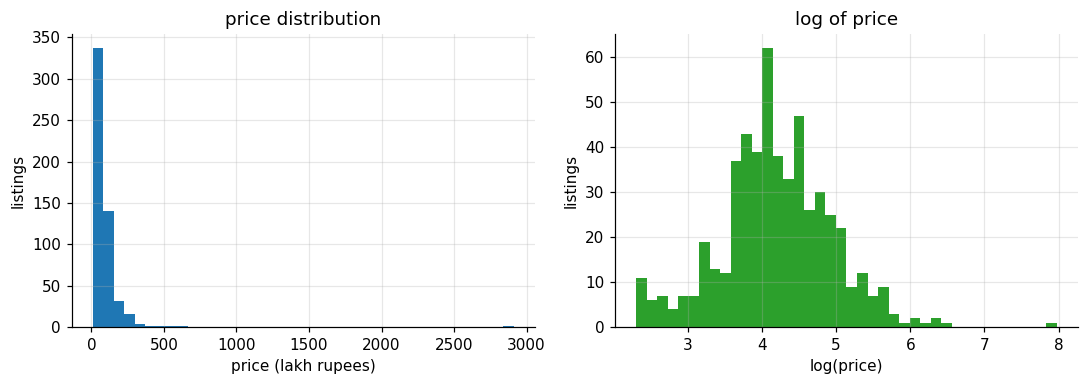

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6))
left.hist(data["price"], bins=40, color="tab:blue")
left.set(title="price distribution", xlabel="price (lakh rupees)", ylabel="listings")
right.hist(np.log(data["price"]), bins=40, color="tab:green")
right.set(title="log of price", xlabel="log(price)", ylabel="listings")
plt.tight_layout()
plt.savefig(FIG / "01_price_distribution.png", bbox_inches="tight")
plt.show()

price is badly lopsided: most listings sit under 150 lakh, but the tail runs all the way to 2,912 lakh (about 29 crore). the log of price looks much closer to a bell curve, which is why the log-transform (step v2) helps a straight-line model so much.

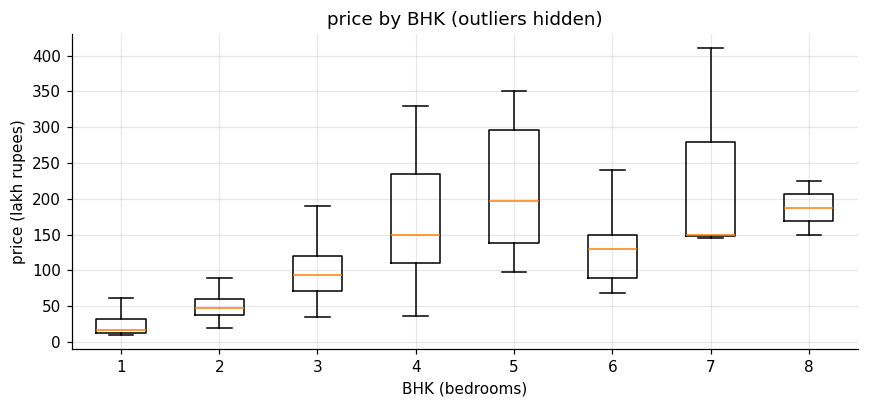

In [6]:
bhks = sorted(data["bhk"].unique())
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot([data.loc[data["bhk"] == b, "price"] for b in bhks], showfliers=False)
ax.set_xticks(range(1, len(bhks) + 1), [f"{int(b)}" for b in bhks])
ax.set(title="price by BHK (outliers hidden)", xlabel="BHK (bedrooms)", ylabel="price (lakh rupees)")
plt.tight_layout()
plt.savefig(FIG / "02_price_by_bhk.png", bbox_inches="tight")
plt.show()

the median price climbs steadily from 1 BHK (about 15 lakh) to 5 BHK (about 200 lakh). after 5 the pattern breaks, because there are only a handful of 6 to 8 BHK listings and they vary a lot.

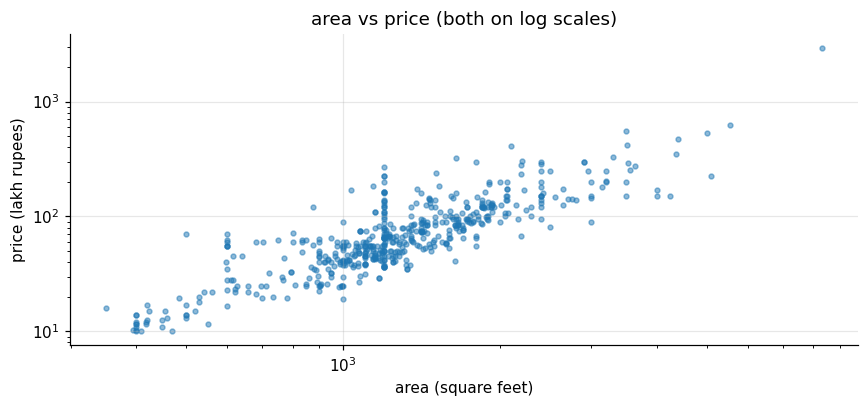

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.scatter(data["area"], data["price"], s=10, alpha=0.5)
ax.set(xscale="log", yscale="log", title="area vs price (both on log scales)",
       xlabel="area (square feet)", ylabel="price (lakh rupees)")
plt.tight_layout()
plt.savefig(FIG / "03_area_vs_price.png", bbox_inches="tight")
plt.show()

on log scales, area and price form a clear straight band: double the area and the price roughly doubles. that straight line on log-log axes is the reason for the final step, the log of area.

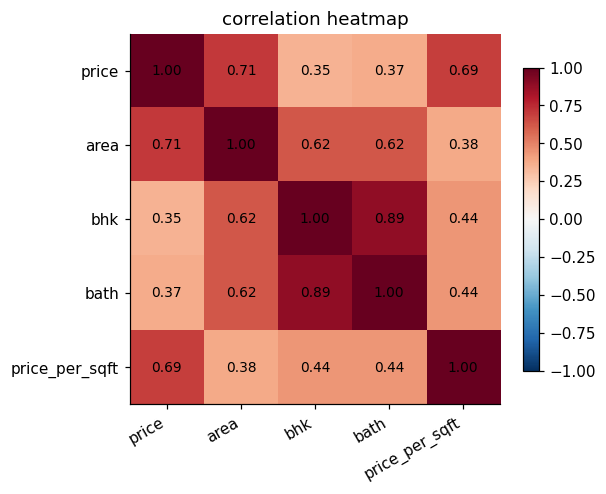

In [8]:
corr = data[["price", "area", "bhk", "bath", "price_per_sqft"]].corr()
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("correlation heatmap")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIG / "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

price moves most with area (0.71) and price per sqft (0.69). bedrooms and bathrooms move together (0.89), so they carry almost the same information, and on their own they say less about price (0.35 and 0.37).

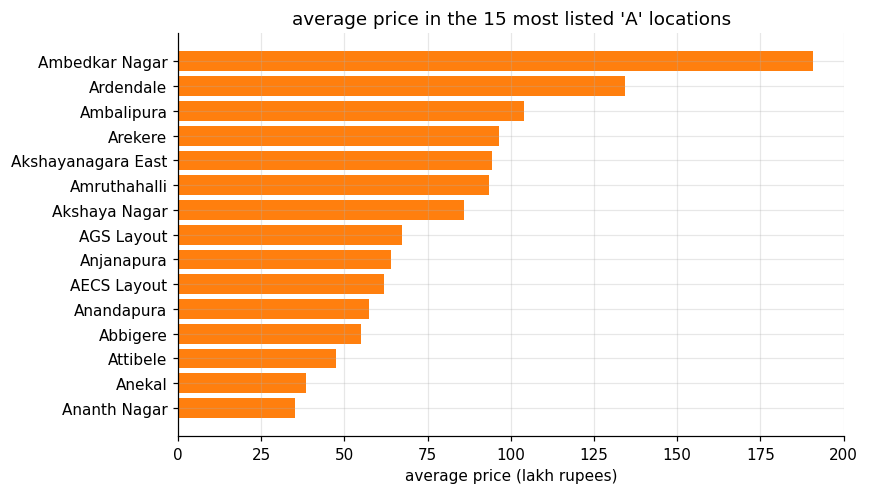

In [9]:
top = data["location"].value_counts().head(15).index
avg = data[data["location"].isin(top)].groupby("location")["price"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(avg.index, avg.values, color="tab:orange")
ax.set(title="average price in the 15 most listed 'A' locations", xlabel="average price (lakh rupees)")
plt.tight_layout()
plt.savefig(FIG / "05_price_by_location.png", bbox_inches="tight")
plt.show()

location matters a lot even inside the "A" areas: an average listing in Ambedkar Nagar costs about 190 lakh, in Ananth Nagar about 35 lakh, over 5 times less. thats why location goes into the model as one-hot columns.

## 6. first model

the handout model: Linear Regression predicting price from area, BHK, bathrooms and location (one-hot encoded, so each location becomes its own 0/1 column). 80/20 train/test split. this first version uses the data exactly as cleaned in section 4.

In [10]:
def build_features(frame, min_listings=1, log_area=False):
    """area, bhk, bath + one-hot location. locations with fewer than min_listings rows become 'other'."""
    counts = frame["location"].value_counts()
    loc = frame["location"].where(frame["location"].map(counts) >= min_listings, "other")
    base = frame[["area", "bhk", "bath"]].assign(area=np.log(frame["area"]) if log_area else frame["area"])
    return pd.get_dummies(base.assign(loc=loc), columns=["loc"], drop_first=True, dtype=float)


def evaluate(frame, log_price=False, min_listings=1, log_area=False):
    """80/20 split + 5-fold cross-validation -> scores, fitted model, test predictions in lakh."""
    X = build_features(frame, min_listings, log_area)
    y = np.log(frame["price"]) if log_price else frame["price"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
    model = LinearRegression().fit(X_tr, y_tr)
    cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                         scoring="r2")
    to_lakh = np.exp if log_price else (lambda v: v)
    actual, pred = to_lakh(y_te), to_lakh(model.predict(X_te))
    scores = {"train R2": r2_score(y_tr, model.predict(X_tr)), "test R2": r2_score(y_te, model.predict(X_te)),
              "5-fold CV R2": cv.mean(), "CV spread": cv.std(),
              "test RMSE (lakh)": np.sqrt(mean_squared_error(actual, pred)),
              "test MAE (lakh)": mean_absolute_error(actual, pred)}
    return scores, model, X, (actual, pred)


v1, *_ = evaluate(data)
print(" | ".join(f"{k} {v:.3f}" for k, v in v1.items()))

train R2 0.764 | test R2 0.403 | 5-fold CV R2 -1.887 | CV spread 4.322 | test RMSE (lakh) 71.783 | test MAE (lakh) 46.126


the first model is poor. it explains 76% of the training rows but only 40% of the test rows, and across 5 different splits it averages -1.89, meaning on some splits its worse than just guessing the average price. a few extreme listings (like the 29 crore one) drag the straight line around.

## 7. iterating until it passes

the handout says to iterate: remove outliers, try a log-transform of price, add or drop features. each step below changes one thing and keeps the rest. the outlier rules are the standard ones for this dataset:

- **sanity rules:** a flat needs at least 300 square feet per bedroom, and no more than 2 bathrooms beyond its bedroom count. anything else is almost certainly a data entry mistake
- **price per square foot:** inside each location, drop listings whose price per square foot is more than 1 standard deviation away from that location's average. a 2 BHK priced like a villa next door is probably a typo or a very unusual property
- **rare locations:** a location seen only once or twice cant be learned, so locations with fewer than 3 listings are grouped into "other"
- **log of area:** price grows with area in percentages, not in fixed steps, so the last step uses log(area) as well

In [11]:
sane = data[(data["area"] / data["bhk"] >= 300) & (data["bath"] <= data["bhk"] + 2)]


def within_location_band(frame):
    keep = []
    for _, group in frame.groupby("location"):
        mean, std = group["price_per_sqft"].mean(), group["price_per_sqft"].std()
        keep.append(group if len(group) <= 2 else
                    group[(group["price_per_sqft"] > mean - std) & (group["price_per_sqft"] <= mean + std)])
    return pd.concat(keep)


banded = within_location_band(sane)
steps = [("v1 cleaned data, price as is", data, False, 1, False),
         ("v2 + log of price", data, True, 1, False),
         ("v3 + sanity rules", sane, True, 1, False),
         ("v4 + price per sqft band", banded, True, 1, False),
         ("v5 + rare locations -> 'other'", banded, True, 3, False),
         ("v6 + log of area (final)", banded, True, 3, True)]
rows = []
for name, frame, log_price, min_listings, log_area in steps:
    scores, *_ = evaluate(frame, log_price, min_listings, log_area)
    rows.append({"step": name, "rows": len(frame), **scores})
iterations = pd.DataFrame(rows).set_index("step")
iterations.round(3)

,rows,train R2,test R2,5-fold CV R2,CV spread,test RMSE (lakh),test MAE (lakh)
step,,,,,,,
"v1 cleaned data, price as is",536,0.764,0.403,-1.887,4.322,71.783,46.126
v2 + log of price,536,0.848,0.787,0.702,0.107,77.040,29.397
v3 + sanity rules,514,0.849,0.578,0.691,0.076,179.545,46.701
v4 + price per sqft band,411,0.912,0.849,0.801,0.040,38.624,18.335
v5 + rare locations -> 'other',411,0.838,0.885,0.813,0.051,31.984,15.373
v6 + log of area (final),411,0.873,0.897,0.855,0.026,33.958,13.936


what each step did (the 5-fold CV column is the honest one, a single 85-row test split jumps around):

- **v2, log of price:** the biggest jump, CV from -1.89 to 0.70. it stops the few crore-plus listings from bending the whole line
- **v3, sanity rules:** removes 22 impossible listings. the single test split dips, but CV barely moves (0.69) and its spread shrinks
- **v4, price per sqft band:** removes listings priced far off their own neighbourhood, CV up to 0.80
- **v5, rare locations:** fewer, sturdier location columns, CV 0.81
- **v6, log of area:** price grows with area in percentages, so log(area) matches the straight line in plot 3. CV 0.855 with the smallest spread (0.026), test R² 0.897

the pass condition (test R² >= 0.75) is met from v4 onwards, and v6 is both the strongest and the most stable.

## 8. checking the final model

one 80/20 split of about 85 test rows can be lucky. so the final model also gets 5-fold cross-validation: 5 different splits, 5 test scores. then the actual vs predicted plot, and what the model learned.

final model: train R2 0.873 | test R2 0.897 | gap -0.025
5-fold cross-validation R2: 0.855 +- 0.026
test RMSE 34.0 lakh | test MAE 13.9 lakh | median test price 66 lakh


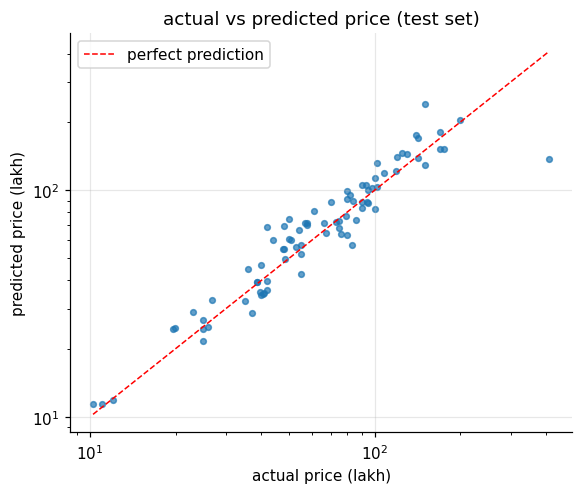

In [12]:
final, model, X_all, (actual, pred) = evaluate(banded, True, 3, True)
train_r2, test_r2 = final["train R2"], final["test R2"]
print(f"final model: train R2 {train_r2:.3f} | test R2 {test_r2:.3f} | gap {train_r2 - test_r2:+.3f}")
print(f"5-fold cross-validation R2: {final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}")
print(f"test RMSE {final['test RMSE (lakh)']:.1f} lakh | test MAE {final['test MAE (lakh)']:.1f} lakh "
      f"| median test price {np.median(actual):.0f} lakh")

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.scatter(actual, pred, s=14, alpha=0.7)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
ax.set(xscale="log", yscale="log", title="actual vs predicted price (test set)",
       xlabel="actual price (lakh)", ylabel="predicted price (lakh)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "06_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [13]:
coef = pd.Series(model.coef_, index=X_all.columns)
print(f"area: 10% bigger -> about {1.1 ** coef['area'] - 1:+.1%} on price")
print(f"one more BHK -> {np.expm1(coef['bhk']):+.0%} | one more bathroom -> {np.expm1(coef['bath']):+.0%}  "
      "(holding the others fixed)")
grouped = banded["location"].where(banded["location"].map(banded["location"].value_counts()) >= 3, "other")
print("baseline location (every other location is compared to it):", sorted(grouped.unique())[0])
loc = coef[coef.index.str.startswith("loc_")].sort_values()
effects = pd.concat([loc.head(4), loc.tail(4)]).rename(lambda c: c.replace("loc_", ""))
np.expm1(effects).mul(100).round(0).to_frame("price vs the baseline location (%)")

area: 10% bigger -> about +11.5% on price
one more BHK -> -2% | one more bathroom -> +2%  (holding the others fixed)
baseline location (every other location is compared to it): AECS Layout


,price vs the baseline location (%)
Ananth Nagar,-37.0
Attibele,-32.0
Abbaiah Reddy Layout,-26.0
Abbigere,-26.0
Ashwathnagar,22.0
Ambedkar Nagar,24.0
Anand Nagar,35.0
Ambedkar Colony,92.0


train R² 0.873 against test R² 0.897: the test score is even a bit higher, so the model is not overfitting (the handout's warning about a big train-test gap doesnt apply). across 5 different splits R² is 0.855 ± 0.026, so 0.897 isnt luck either. the typical error (MAE) is about 14 lakh on a median test price of 66 lakh.

the plot shows the predictions hugging the diagonal. the clear miss is one very expensive listing (about 400 lakh actual, about 130 predicted): there are too few luxury homes in my subset to learn that end.

what the model learned, holding everything else fixed:

- **area:** 10% bigger means about 11.5% more expensive. the strongest effect
- **BHK and bathrooms:** -2% and +2%, tiny. once area is known, an extra bedroom mostly just means smaller rooms
- **location:** from about 37% cheaper (Ananth Nagar) to 92% pricier (Ambedkar Colony) than the baseline location, AECS Layout

## 9. summary

**what affected price the most.** area is the biggest driver: in my subset of "A" locations, a 10% bigger flat costs about 11.5% more, and area alone correlates 0.71 with price. location comes second, and its big: average prices differ over 5 times between the cheapest and the costliest "A" areas, and the model puts locations from about 37% below to 92% above the baseline (AECS Layout). once area is known, bedrooms and bathrooms barely matter (-2% and +2%), because more bedrooms in the same space only means smaller rooms.

**why the final model performs as it does.** the raw data breaks a straight-line model in two ways: prices are hugely skewed (a few listings cost crores), and some listings are impossible or priced far off their neighbourhood (data entry mistakes or one-off properties). taking logs of price and area turns the relationship into a straight line, which is exactly what linear regression fits, and the outlier rules remove listings no simple model should chase. that took the test R² from 0.40 to 0.897, with 5-fold cross-validation at 0.855 ± 0.026 and no train-test gap.

**limits.** the outlier steps removed 125 of 536 listings, so the model is built for typical flats, not luxury homes or one-off plots. with only 411 rows, locations seen fewer than 3 times are lumped into "other", so the model knows nothing specific about them.

In [14]:
summary = pd.Series({
    "subset": f"locations starting with 'A', {len(df[starts_with_a])} rows",
    "rows used by the final model": f"{len(banded)}",
    "final model": "Linear Regression: log(price) from log(area), BHK, bathrooms, location",
    "train R2 / test R2": f"{train_r2:.3f} / {test_r2:.3f}",
    "5-fold cross-validation R2": f"{final['5-fold CV R2']:.3f} +- {final['CV spread']:.3f}",
    "test RMSE / MAE": f"{final['test RMSE (lakh)']:.1f} / {final['test MAE (lakh)']:.1f} lakh",
    "pass condition (test R2 >= 0.75)": "passed" if test_r2 >= 0.75 else "not passed",
}, name="value")
summary.to_frame()

,value
subset,"locations starting with 'A', 568 rows"
rows used by the final model,411
final model,"Linear Regression: log(price) from log(area), ..."
train R2 / test R2,0.873 / 0.897
5-fold cross-validation R2,0.855 +- 0.026
test RMSE / MAE,34.0 / 13.9 lakh
pass condition (test R2 >= 0.75),passed
